<a href="https://colab.research.google.com/github/aeshapatel123/IN126053102_NLP-PREPROCESSING-ENGINE/blob/main/TASK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sentimental Analysis using NLP and Machine learning using the IMDB dataset from Kaggle

In [ ]:
# =========================
# 1. Import Libraries
# =========================

import pandas as pd
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Download required NLTK files
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

In [ ]:
# =========================
# 2. Uploading the dataset
# =========================
from google.colab import files
files.upload()

In [ ]:
import os
print(os.listdir())

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

Step 1: Check the columns in the dataset

In [ ]:
print(train_df.columns)

In [ ]:
train_df.head()

Step 2: Check class distribution

In [ ]:
#Check sentiment distribution
print(train_df['sentiment'].value_counts())

Step 3: Convert labels into numbers

In [ ]:
#Convert labels into numbers
train_df['sentiment'] = train_df['sentiment'].map({'pos': 1, 'neg': 0})
test_df['sentiment'] = test_df['sentiment'].map({'pos': 1, 'neg': 0})

In [ ]:
train_df.head()

Step 4: Import NLP libraries for preprocessing

In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

Step 5: Create the preprocessing function

In [ ]:
# =========================
# 3. Text Preprocessing
# =========================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # convert to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [ ]:
nltk.download('punkt_tab')

Step 6: Apply preprocessing to both datasets

In [ ]:
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

In [ ]:
train_df[['text', 'clean_text']].head()

Step 7: Convert cleaned text into Bag of Words features

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(train_df['clean_text'])
X_test_bow = bow.transform(test_df['clean_text'])

y_train = train_df['sentiment']
y_test = test_df['sentiment']

In [ ]:
print(X_train_bow.shape)
print(X_test_bow.shape)

Step 8: Create TF-IDF features

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])

In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

Step 9: Create an evaluation function

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(name, model, X_test, y_test):

    y_pred = model.predict(X_test)

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

Step 10: Train and evaluate Logistic Regression using Bag of Words

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_bow = LogisticRegression(max_iter=1000)

lr_bow.fit(X_train_bow, y_train)

evaluate_model(
    "Logistic Regression (BoW)",
    lr_bow,
    X_test_bow,
    y_test
)

Naive Bayes with Bag of Words.

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_bow = MultinomialNB()

nb_bow.fit(X_train_bow, y_train)

evaluate_model(
    "Naive Bayes (BoW)",
    nb_bow,
    X_test_bow,
    y_test
)

Decision Tree with Bag of Words:

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_bow = DecisionTreeClassifier(random_state=42)

dt_bow.fit(X_train_bow, y_train)

evaluate_model(
    "Decision Tree (BoW)",
    dt_bow,
    X_test_bow,
    y_test
)

TF-IDF with Logistic Regression:

In [ ]:
lr_tfidf = LogisticRegression(max_iter=1000)

lr_tfidf.fit(X_train_tfidf, y_train)

evaluate_model(
    "Logistic Regression (TF-IDF)",
    lr_tfidf,
    X_test_tfidf,
    y_test
)

Naive Bayes with TF-IDF

In [ ]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(X_train_tfidf, y_train)

evaluate_model(
    "Naive Bayes (TF-IDF)",
    nb_tfidf,
    X_test_tfidf,
    y_test
)

Decision Tree with TF-IDF

In [ ]:
dt_tfidf = DecisionTreeClassifier(random_state=42)

dt_tfidf.fit(X_train_tfidf, y_train)

evaluate_model(
    "Decision Tree (TF-IDF)",
    dt_tfidf,
    X_test_tfidf,
    y_test
)

All required model results.

Our final ranking is:

1. Logistic Regression + TF-IDF → Accuracy 0.87684, F1 0.87725
2. Logistic Regression + BoW → Accuracy 0.84392, F1 0.84247
3. Naive Bayes + TF-IDF → Accuracy 0.83852, F1 0.83524
4. Naive Bayes + BoW → Accuracy 0.83364, F1 0.82871
5. Decision Tree + BoW → Accuracy 0.71320, F1 0.71016
6. Decision Tree + TF-IDF → Accuracy 0.71016, F1 0.70640

Final Step: Add a sample prediction cell

In [ ]:
sample = ["This movie was absolutely amazing and I loved every part of it"]

sample_clean = [preprocess_text(text) for text in sample]

sample_vector = tfidf.transform(sample_clean)

prediction = lr_tfidf.predict(sample_vector)

if prediction[0] == 1:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")

A bar graph of model accuracies

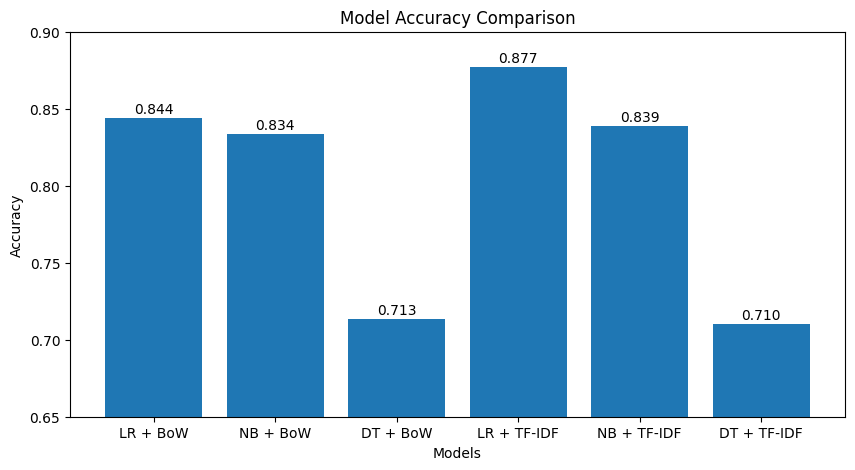

In [2]:
import matplotlib.pyplot as plt

models = [
    "LR + BoW",
    "NB + BoW",
    "DT + BoW",
    "LR + TF-IDF",
    "NB + TF-IDF",
    "DT + TF-IDF"
]

accuracies = [0.84392, 0.83364, 0.71320, 0.87684, 0.83852, 0.71016]

plt.figure(figsize=(10,5))
bars = plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.65, 0.90)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.003,
        f"{y:.3f}",
        ha='center'
    )

plt.show()

F1-score graph:

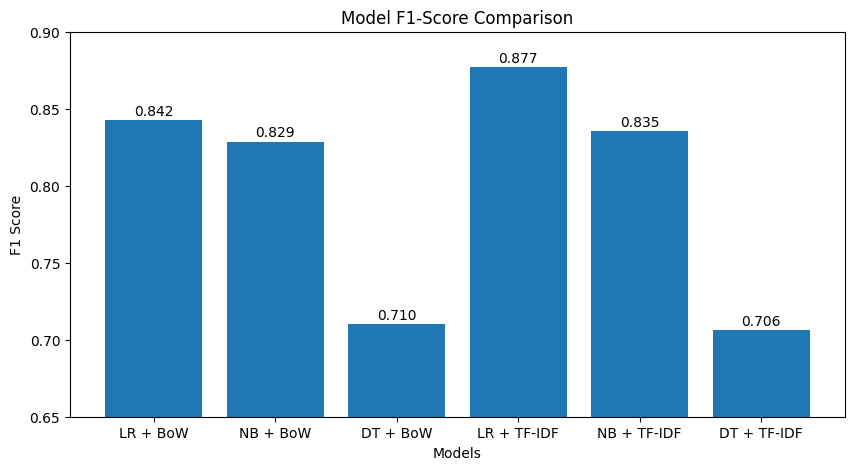

In [3]:
f1_scores = [0.84247, 0.82871, 0.71016, 0.87725, 0.83524, 0.70640]

plt.figure(figsize=(10,5))
bars = plt.bar(models, f1_scores)

plt.title("Model F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.ylim(0.65, 0.90)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.003,
        f"{y:.3f}",
        ha='center'
    )

plt.show()